In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

In [10]:
df = pd.read_csv("E:\\AIML-Projects\\gamegpt\\data\\steam_clean.csv")

In [11]:
print(df['genres'].unique()[:20])
print(df['genres'].value_counts().head(20))

<StringArray>
[                               'Action',
                   'Action;Free to Play',
          'Action;Free to Play;Strategy',
                      'Action;Adventure',
                                 'Indie',
                        'Indie;Strategy',
                              'Strategy',
                                   'RPG',
 'Animation & Modeling;Video Production',
                            'Action;RPG',
                      'Action;Indie;RPG',
                          'Casual;Indie',
                 'Action;Indie;Strategy',
            'Action;Simulation;Strategy',
                   'Simulation;Strategy',
                     'Action;Simulation',
                                'Racing',
                          'RPG;Strategy',
                      'Adventure;Casual',
                                'Casual']
Length: 20, dtype: str
genres
Action;Indie                     1852
Casual;Indie                     1481
Action;Adventure;Indie           1228
Ad

In [12]:
# Split genres and explode into individual rows
genres_split = df['genres'].str.split(';').explode()
print(genres_split.value_counts().head(15))

genres
Indie                    19410
Action                   11896
Casual                   10204
Adventure                10027
Strategy                  5246
Simulation                5192
RPG                       4307
Early Access              2952
Free to Play              1701
Sports                    1322
Racing                    1024
Violent                    842
Massively Multiplayer      721
Gore                       537
Nudity                     266
Name: count, dtype: int64


                   genres  owners_midpoint
0                  Action     2.361490e+09
1                   Indie     1.457670e+09
2               Adventure     1.101670e+09
3            Free to Play     1.009785e+09
4                Strategy     7.680400e+08
5                     RPG     6.968250e+08
6                  Casual     5.466800e+08
7              Simulation     5.259050e+08
8   Massively Multiplayer     4.462300e+08
9            Early Access     1.554850e+08
10                 Sports     1.040200e+08
11                 Racing     8.630000e+07
12                Violent     4.089500e+07
13                   Gore     2.578500e+07
14                 Nudity     2.239000e+07


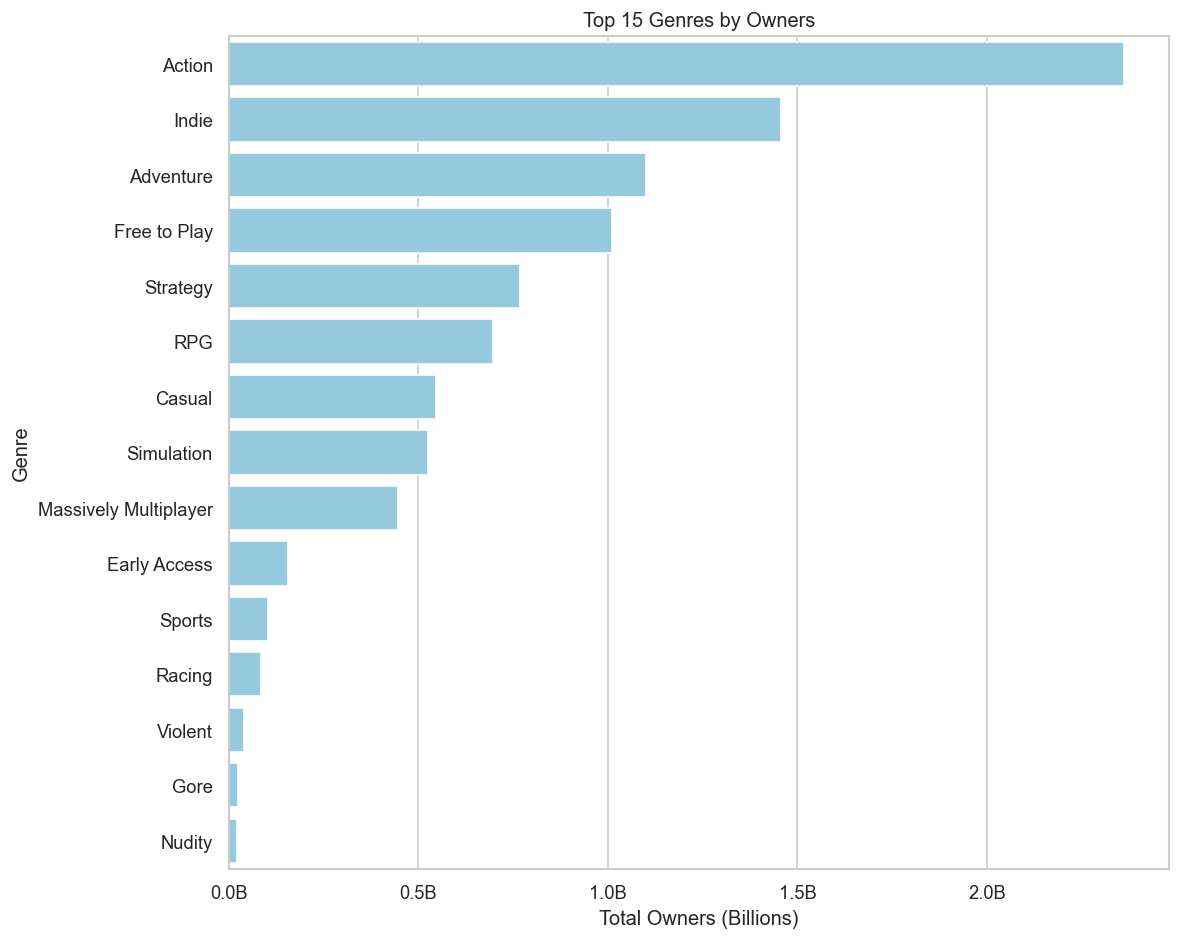

In [ ]:
# Step 1: Create a dataframe with just name, genres, owners_midpoint
genre_owners = df[['name', 'genres', 'owners_midpoint']].copy()

# Step 2: Split genres into individual rows
genre_owners['genres'] = genre_owners['genres'].str.split(';')
genre_owners = genre_owners.explode('genres')

# Step 3: Group by genre and get total owners
genre_group = genre_owners.groupby('genres')['owners_midpoint'].sum().sort_values(ascending=False).head(15).reset_index()
print(genre_group)

# Step 4: Plot top 15 genres by owners
plt.figure(figsize=(10,8))

sns.barplot(data=genre_group, x='owners_midpoint', y='genres', color='skyblue')

plt.title('Top 15 Genres by Owners')
plt.xlabel('Total Owners (Billions)')
plt.ylabel('Genre')

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e9:.1f}B'))

plt.tight_layout()
plt.savefig("E:\\AIML-Projects\\gamegpt\\reports\\figures\\genre_by_owners.png", dpi=150, bbox_inches='tight')

plt.show()